# LightFM Feature Importance vs Accuracy

This notebook uses the processed dataset to estimate which item features help or hurt LightFM accuracy.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.dataloader.ratings_splitter import RatingsSplitter
from src.evaluation import LightFMFeatureInfluenceAnalyzer
from src.evaluation import LightFMFeatureInfluenceConfig

## Load Processed Data

We load cleaned ratings and movie features from `data/processed`.

In [13]:
project_root_path = Path.cwd()
if not (project_root_path / "src").exists():
    project_root_path = project_root_path.parent

ratings_path = project_root_path / "data" / "processed" / "ratings_train_cleaned.csv"
movies_path = project_root_path / "data" / "processed" / "movies_cleaned.csv"

ratings_dataframe = pd.read_csv(ratings_path)
movies_dataframe = pd.read_csv(movies_path)

print(f"Ratings rows: {len(ratings_dataframe)}")
print(f"Movies rows: {len(movies_dataframe)}")

Ratings rows: 97801
Movies rows: 9742


## Create Train/Validation Split

To keep enough train signal, we hold out 30% interactions for only 50 users. Users with <= 1 interaction are excluded.

In [14]:
splitter = RatingsSplitter(
    val_fraction=0.3,
    min_interactions=2,
    seed=42,
    max_validation_users=50,
)

train_dataframe, validation_dataframe = splitter.split(ratings_dataframe)

print(f"Train rows: {len(train_dataframe)}")
print(f"Validation rows: {len(validation_dataframe)}")
print(f"Validation users: {validation_dataframe['userId'].nunique()}")

Train rows: 95251
Validation rows: 2550
Validation users: 50


## Run Feature Influence Analysis

This performs one-feature-at-a-time ablation and compares RMSE against the baseline model.

- Positive influence score: removing feature makes RMSE worse (feature helps).
- Negative influence score: removing feature improves RMSE (feature hurts).

In [15]:
influence_config = LightFMFeatureInfluenceConfig(
    metric_name="rmse_value",
    number_of_recommendations=10,
    relevance_threshold=4.0,
    number_of_components=30,
    number_of_epochs=32,
    learning_rate_value=0.001,
    loss_name="bpr",
    random_seed=42,
)

analyzer = LightFMFeatureInfluenceAnalyzer(influence_config=influence_config)
feature_influence_dataframe = analyzer.analyze(
    train_dataframe=train_dataframe,
    validation_dataframe=validation_dataframe,
    movies_dataframe=movies_dataframe,
)

feature_influence_dataframe.head(20)

,feature_name,baseline_metric_value,ablated_metric_value,influence_score,influence_direction
0,genre_Drama,3.891306,3.922239,0.030934,positive
1,genre_Crime,3.891306,3.907635,0.016329,positive
2,genre_Action,3.891306,3.906144,0.014838,positive
3,genre_Adventure,3.891306,3.900980,0.009674,positive
4,genre_Thriller,3.891306,3.900795,0.009489,positive
5,genre_Sci-Fi,3.891306,3.898382,0.007076,positive
6,genre_Romance,3.891306,3.896920,0.005614,positive
7,genre_War,3.891306,3.895342,0.004036,positive
8,genre_Mystery,3.891306,3.893924,0.002618,positive
9,genre_IMAX,3.891306,3.893386,0.002081,positive


## Best Positive and Negative Features

Here we inspect the strongest contributors and the strongest harmful features.

In [16]:
top_positive_features = feature_influence_dataframe.head(10).copy()
top_negative_features = feature_influence_dataframe.tail(10).copy()

print("Top positive features (help RMSE):")
display(top_positive_features[["feature_name", "influence_score", "influence_direction"]])

print("Top negative features (hurt RMSE):")
display(top_negative_features[["feature_name", "influence_score", "influence_direction"]])

,feature_name,influence_score,influence_direction
11,genre_Musical,0.001143,positive
12,genre_Animation,0.000501,positive
13,release_year,0.000426,positive
14,genre_Film-Noir,0.000307,positive
15,genre_Western,0.000135,positive
16,genre_(no genres listed),-0.000005,negative
17,genre_Documentary,-0.000073,negative
18,genre_Children,-0.001752,negative
19,genre_Horror,-0.003017,negative
20,genre_Comedy,-0.019445,negative


## Visualize Feature Influence

Bars above zero help accuracy (lower RMSE), bars below zero hurt it.

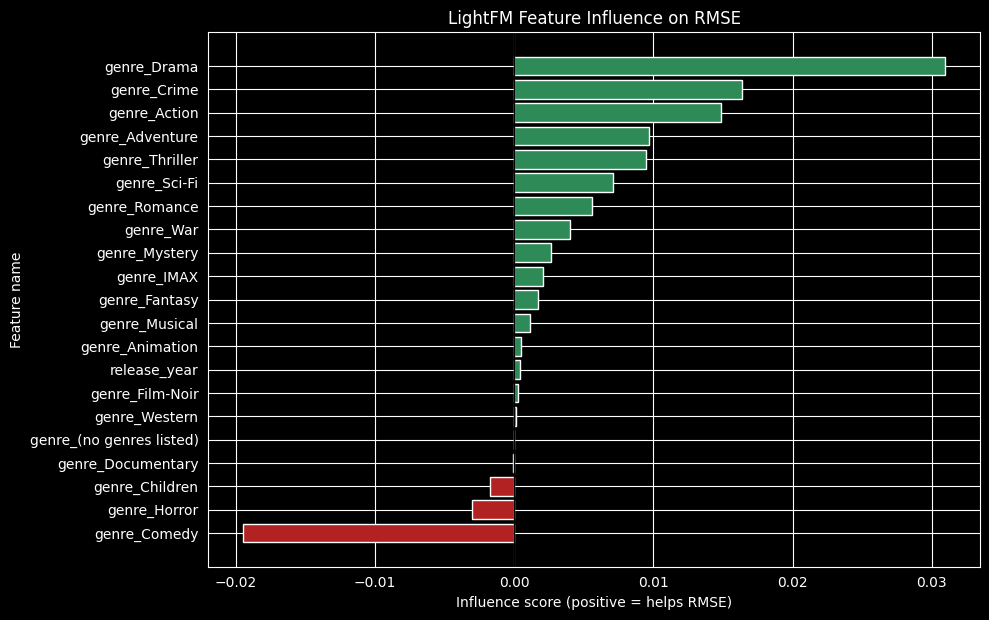

In [17]:
plot_dataframe = feature_influence_dataframe.sort_values("influence_score", ascending=True).copy()
plot_colors = ["#2E8B57" if value >= 0 else "#B22222" for value in plot_dataframe["influence_score"]]

plt.figure(figsize=(10, max(6, len(plot_dataframe) * 0.3)))
plt.barh(plot_dataframe["feature_name"], plot_dataframe["influence_score"], color=plot_colors)
plt.axvline(0.0, color="black", linewidth=1)
plt.title("LightFM Feature Influence on RMSE")
plt.xlabel("Influence score (positive = helps RMSE)")
plt.ylabel("Feature name")
plt.tight_layout()
plt.show()